In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
DB_USER = "postgres"
DB_PASSWORD = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "sales_analytics_db"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [5]:
fact_sales = pd.read_sql("SELECT * FROM fact_sales;", engine)
monthly_sales = pd.read_sql("SELECT * FROM vw_monthly_sales;", engine)
product_perf = pd.read_sql("SELECT * FROM vw_product_performance;", engine)

In [6]:
monthly_sales.head()
monthly_sales.info()
monthly_sales.describe()
print(fact_sales.shape, monthly_sales.shape, product_perf.shape)

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   month_start      35 non-null     datetime64[us, UTC]
 1   monthly_revenue  35 non-null     float64            
 2   monthly_cost     35 non-null     float64            
 3   monthly_profit   35 non-null     float64            
 4   total_quantity   35 non-null     int64              
dtypes: datetime64[us, UTC](1), float64(3), int64(1)
memory usage: 1.5 KB
(57851, 13) (35, 5) (0, 4)


In [10]:
monthly_sales['month_start'] = pd.to_datetime(monthly_sales['month_start'])
monthly_sales = monthly_sales.sort_values('month_start')

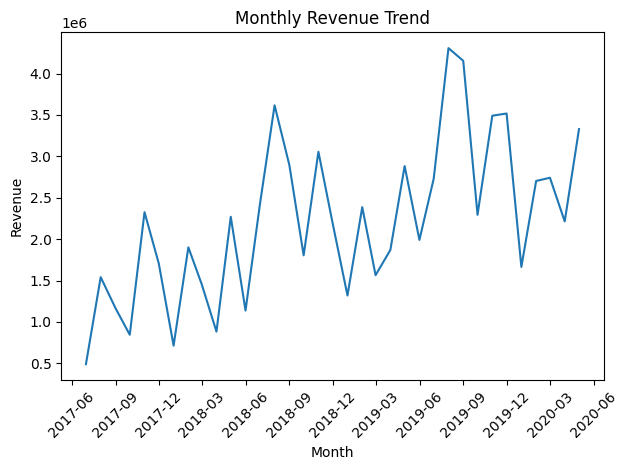

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure()

plt.plot(monthly_sales['month_start'], monthly_sales['monthly_revenue'])

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # every 3 months

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [13]:
monthly_sales['profit_margin'] = (
    monthly_sales['monthly_profit'] / monthly_sales['monthly_revenue']
)

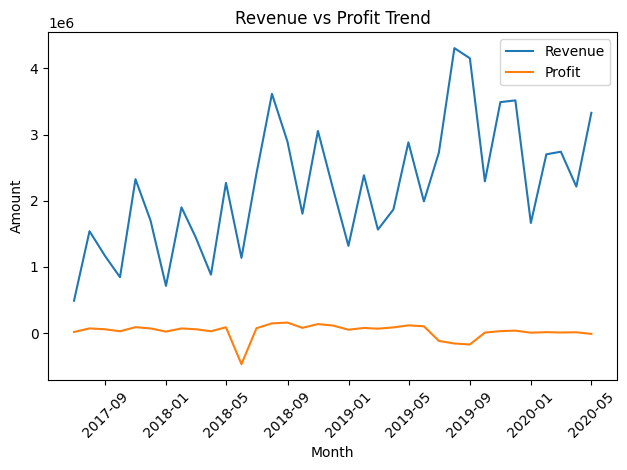

In [14]:
plt.figure()

plt.plot(monthly_sales['month_start'], monthly_sales['monthly_revenue'], label='Revenue')
plt.plot(monthly_sales['month_start'], monthly_sales['monthly_profit'], label='Profit')

plt.legend()
plt.title("Revenue vs Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

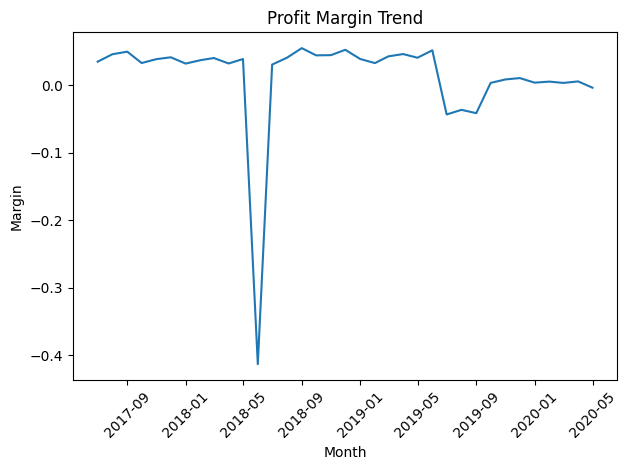

In [15]:
plt.figure()

plt.plot(monthly_sales['month_start'], monthly_sales['profit_margin'])

plt.title("Profit Margin Trend")
plt.xlabel("Month")
plt.ylabel("Margin")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

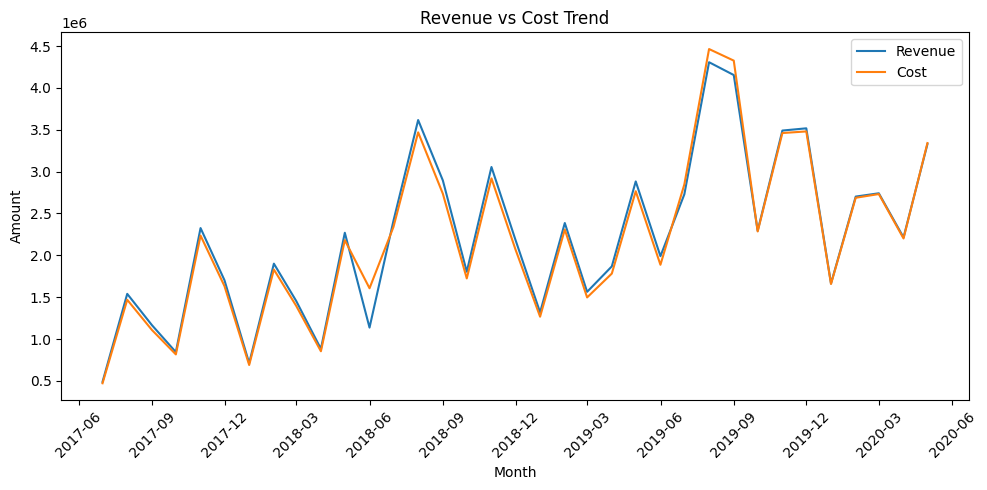

In [23]:
monthly_sales['month_start'] = pd.to_datetime(monthly_sales['month_start'], utc=True).dt.tz_localize(None)
monthly_sales = monthly_sales.sort_values('month_start')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales['month_start'], monthly_sales['monthly_revenue'], label='Revenue')
plt.plot(monthly_sales['month_start'], monthly_sales['monthly_cost'], label='Cost')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.title("Revenue vs Cost Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

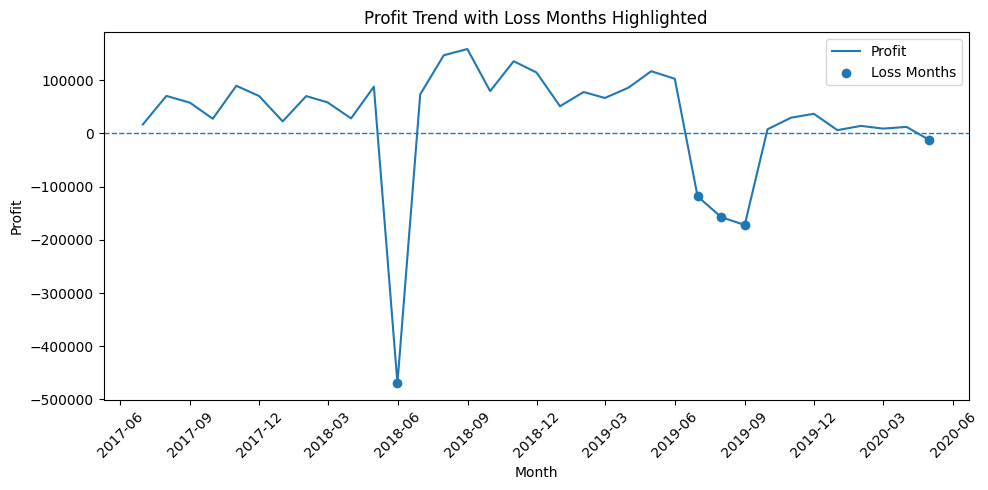

In [24]:
loss_data = monthly_sales[monthly_sales['monthly_profit'] < 0]

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales['month_start'], monthly_sales['monthly_profit'], label='Profit')
plt.scatter(
    loss_data['month_start'],
    loss_data['monthly_profit'],
    label='Loss Months'
)

plt.axhline(0, linestyle='--', linewidth=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.title("Profit Trend with Loss Months Highlighted")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
loss_summary = loss_months.copy()

loss_summary['month_start'] = pd.to_datetime(loss_summary['month_start'], utc=True).dt.tz_localize(None)
loss_summary['month_label'] = loss_summary['month_start'].dt.strftime('%Y-%m')

total_loss = abs(loss_summary['monthly_profit'].sum())

print(f"Total Loss from Loss Months: {total_loss:,.2f}")
print("\nLoss-making Months Summary:\n")
print(
    loss_summary[['month_label', 'monthly_revenue', 'monthly_cost', 'monthly_profit', 'profit_margin']]
)

Total Loss from Loss Months: 929,732.41

Loss-making Months Summary:

   month_label  monthly_revenue  monthly_cost  monthly_profit  profit_margin
11     2018-05       1137251.90    1607008.32      -469756.42      -0.413063
24     2019-06       2729167.03    2847508.32      -118341.29      -0.043362
25     2019-07       4306549.14    4463793.70      -157244.56      -0.036513
26     2019-08       4153399.35    4325499.37      -172100.02      -0.041436
34     2020-04       3328607.46    3340897.58       -12290.12      -0.003692


In [25]:
print(monthly_sales.loc[monthly_sales['monthly_profit'].idxmin()])

month_start        2018-05-31 18:30:00
monthly_revenue              1137251.9
monthly_cost                1607008.32
monthly_profit              -469756.42
total_quantity                    2204
profit_margin                -0.413063
Name: 11, dtype: object


In [26]:
monthly_sales[
    (monthly_sales['month_start'] >= '2018-03-01') &
    (monthly_sales['month_start'] <= '2018-07-31')
][['month_start', 'monthly_revenue', 'monthly_cost', 'monthly_profit']]

,month_start,monthly_revenue,monthly_cost,monthly_profit
9,2018-03-31 18:30:00,883010.98,854646.13,28364.85
10,2018-04-30 18:30:00,2269719.87,2181837.96,87881.91
11,2018-05-31 18:30:00,1137251.90,1607008.32,-469756.42
12,2018-06-30 18:30:00,2411558.85,2338001.36,73557.49


In [27]:
avg_cost = monthly_sales['monthly_cost'].mean()
avg_revenue = monthly_sales['monthly_revenue'].mean()

may_2018 = monthly_sales.loc[monthly_sales['monthly_profit'].idxmin()]

print("Avg Cost:", avg_cost)
print("May Cost:", may_2018['monthly_cost'])

print("\nAvg Revenue:", avg_revenue)
print("May Revenue:", may_2018['monthly_revenue'])

Avg Cost: 2187116.4465714283
May Cost: 1607008.32

Avg Revenue: 2215673.4342857143
May Revenue: 1137251.9


In [31]:
fact_sales['orderdate'] = pd.to_datetime(fact_sales['orderdate'])

may_data = fact_sales[
    (fact_sales['orderdate'] >= '2018-05-01') &
    (fact_sales['orderdate'] <= '2018-05-31')
]

print(may_data.head())
print(may_data.shape)

   salesordernumber  orderdate  order_year  order_month  productkey  \
11          SO46082 2018-05-23      2018.0          5.0         220   
12          SO46082 2018-05-23      2018.0          5.0         346   
13          SO46082 2018-05-23      2018.0          5.0         345   
14          SO46082 2018-05-23      2018.0          5.0         232   
15          SO46082 2018-05-23      2018.0          5.0         344   

    resellerkey  employeekey  salesterritorykey  quantity  unitprice  revenue  \
11          312          282                  4         2      20.19    40.38   
12          312          282                  4         2    2039.99  4079.98   
13          312          282                  4         2    2039.99  4079.98   
14          312          282                  4         2      28.84    57.68   
15          312          282                  4         2    2039.99  4079.98   

    totalproductcost  profit  
11             24.06   16.32  
12           3824.31  25

In [32]:
print(fact_sales['orderdate'].dtype)

datetime64[s]


In [39]:
product_perf = pd.read_sql("SELECT * FROM vw_product_performance;", engine)
print(product_perf.head())
print(product_perf.shape)
print(product_perf.columns)

   productkey  total_revenue  total_orders
0         359     1472920.24           296
1         358     1471745.64           343
2         360     1362221.16           319
3         583     1283443.06           308
4         576     1263913.32           260
(334, 3)
Index(['productkey', 'total_revenue', 'total_orders'], dtype='str')


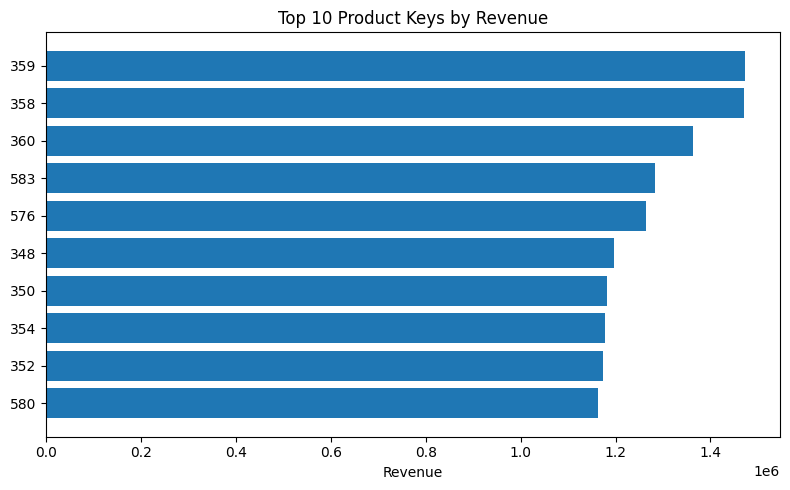

In [40]:
top_products = product_perf.head(10).copy()
top_products['total_revenue'] = pd.to_numeric(top_products['total_revenue'], errors='coerce')

plt.figure(figsize=(8, 5))
plt.barh(top_products['productkey'].astype(str), top_products['total_revenue'])
plt.title("Top 10 Product Keys by Revenue")
plt.xlabel("Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [41]:
monthly_sales.to_csv("monthly_sales_clean.csv", index=False)
product_perf.to_csv("product_performance.csv", index=False)